1️⃣ Load dataset
2️⃣ Dataset shape 

In [1]:
import pandas as pd

df = pd.read_csv("event_dataset_raw.csv")

df.shape


(107, 21)

3️⃣ Sample rows

In [58]:
df.head()

,video_id,video_name,camera_name,window_start_sec,window_end_sec,max_confidence,avg_confidence,object_count,fire_smoke_ratio,bbox_area_ratio,detection_density_5s,detection_density_10s,avg_confidence_5s,consecutive_fire_ratio,bbox_area_growth,brightness,blur_score,motion_level
0,1,cam01_car_fire.mp4,cam01,0,5,0.956676,0.507682,4.442953,0.725076,0.754938,4.413333,2.206667,0.507682,0.993333,0.131600,117.636522,306.559966,15.075118
1,1,cam01_car_fire.mp4,cam01,1,6,0.956676,0.531307,4.040000,0.717822,0.754938,4.040000,2.410000,0.531307,1.000000,-0.449193,118.668447,305.462107,14.110983
2,1,cam01_car_fire.mp4,cam01,2,7,0.974603,0.549537,4.033333,0.795041,0.704905,4.033333,2.930000,0.549537,1.000000,0.049185,121.241233,321.499933,16.065058
3,1,cam01_car_fire.mp4,cam01,3,8,0.974603,0.547429,4.520000,0.824484,0.785613,4.520000,3.640000,0.547429,1.000000,0.154965,120.615053,353.277080,17.275827
4,1,cam01_car_fire.mp4,cam01,4,9,0.974603,0.566568,5.446667,0.848225,0.785613,5.446667,4.436667,0.566568,1.000000,1.411814,119.331640,389.828220,17.402698


4️⃣ Feature statistics

In [59]:
df.describe().round(3)

,video_id,window_start_sec,window_end_sec,max_confidence,avg_confidence,object_count,fire_smoke_ratio,bbox_area_ratio,detection_density_5s,detection_density_10s,avg_confidence_5s,consecutive_fire_ratio,bbox_area_growth,brightness,blur_score,motion_level
count,107.000,107.000,107.000,107.000,107.000,107.000,107.000,107.000,107.000,107.000,107.000,107.000,107.000,107.000,107.000,107.000
mean,3.654,34.813,39.813,0.770,0.459,7.660,0.785,0.706,7.188,6.972,0.459,0.954,0.027,107.976,395.969,5.232
std,0.790,27.304,27.304,0.131,0.062,5.187,0.199,0.142,4.528,3.832,0.062,0.169,0.452,19.663,227.455,3.326
min,1.000,0.000,5.000,0.359,0.278,1.000,0.352,0.253,0.073,1.228,0.278,0.047,-0.990,68.153,147.970,1.491
25%,4.000,7.500,12.500,0.701,0.412,4.037,0.632,0.672,4.015,4.144,0.412,0.994,-0.172,93.781,232.743,3.007
50%,4.000,32.000,37.000,0.777,0.459,6.293,0.837,0.740,6.240,6.687,0.459,1.001,0.044,107.799,320.335,4.554
75%,4.000,58.500,63.500,0.887,0.513,9.103,0.967,0.794,8.782,8.792,0.513,1.001,0.181,121.194,467.249,5.647
max,4.000,85.000,90.000,0.975,0.583,22.991,1.000,0.877,21.668,16.416,0.583,1.001,3.000,147.658,1097.739,17.403


In [5]:
import pandas as pd

df = pd.read_csv("event_dataset_raw.csv")
df.columns

Index(['video_id', 'video_name', 'camera_name', 'window_start_sec',
       'window_end_sec', 'representative_frame_id',
       'representative_frame_name', 'representative_frame_path',
       'max_confidence', 'avg_confidence', 'object_count', 'fire_smoke_ratio',
       'bbox_area_ratio', 'detection_density_5s', 'detection_density_10s',
       'avg_confidence_5s', 'consecutive_fire_ratio', 'bbox_area_growth',
       'brightness', 'blur_score', 'motion_level'],
      dtype='str')

1️⃣ Detection density (5s window)

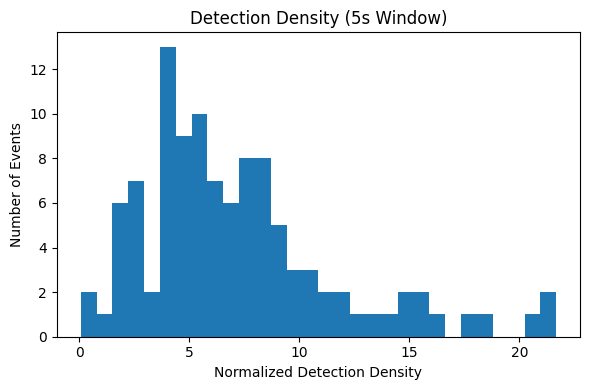

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
df["detection_density_5s"].hist(bins=30)
plt.title("Detection Density (5s Window)")
plt.xlabel("Normalized Detection Density")
plt.ylabel("Number of Events")
plt.tight_layout()
plt.grid(False)
plt.show()

2️⃣ Detection density (10s window)

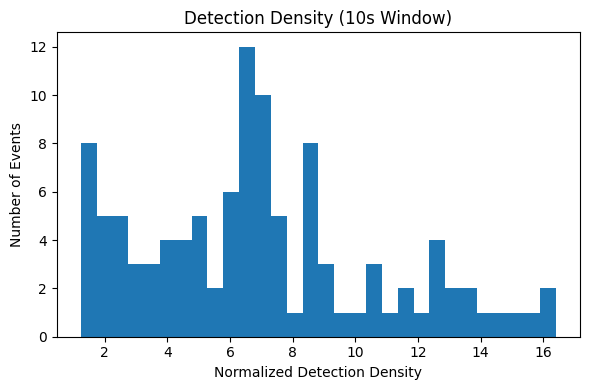

In [61]:
plt.figure(figsize=(6, 4))
df["detection_density_10s"].hist(bins=30)
plt.title("Detection Density (10s Window)")
plt.xlabel("Normalized Detection Density")
plt.ylabel("Number of Events")
plt.tight_layout()
plt.grid(False)
plt.show()

3️⃣ Consecutive fire frames — TEMPORAL STABILITY

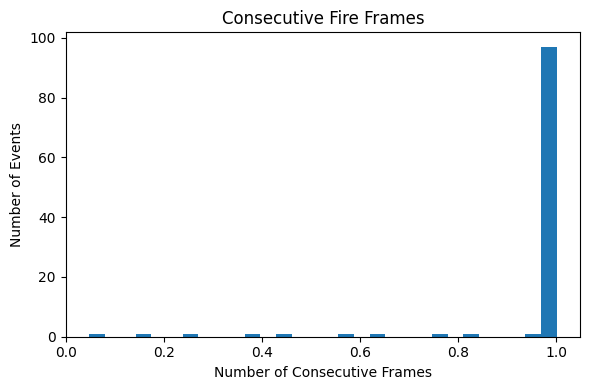

In [62]:
plt.figure(figsize=(6, 4))
df["consecutive_fire_ratio"].hist(bins=30)
plt.title("Consecutive Fire Frames")
plt.xlabel("Number of Consecutive Frames")
plt.ylabel("Number of Events")
plt.tight_layout()
plt.grid(False)
plt.show()


4️⃣ Bounding box area growth — SPATIAL BEHAVIOR

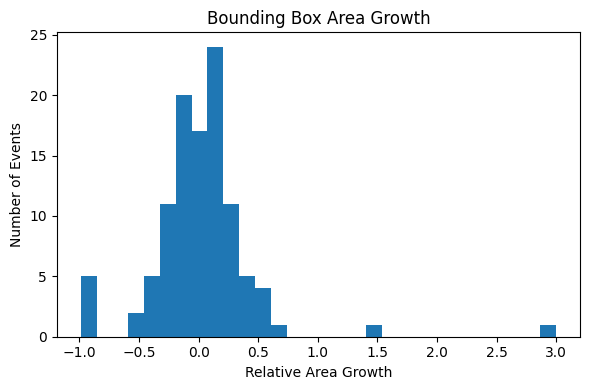

In [63]:
plt.figure(figsize=(6, 4))
df["bbox_area_growth"].hist(bins=30)
plt.title("Bounding Box Area Growth")
plt.xlabel("Relative Area Growth")
plt.ylabel("Number of Events")
plt.tight_layout()
plt.grid(False)
plt.show()

5️⃣ (Optional) Confidence distribution

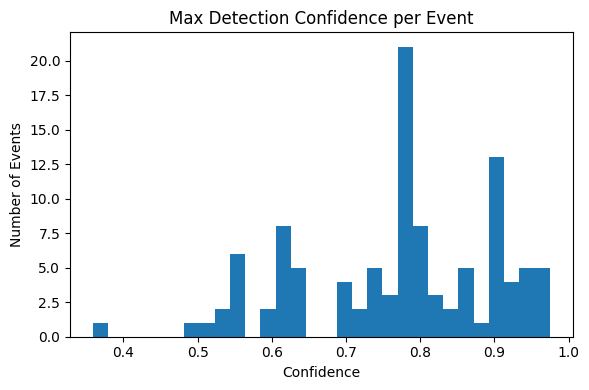

In [64]:
plt.figure(figsize=(6, 4))
df["max_confidence"].hist(bins=30)
plt.title("Max Detection Confidence per Event")
plt.xlabel("Confidence")
plt.ylabel("Number of Events")
plt.tight_layout()
plt.grid(False)
plt.show()

Current label distribution (evidence)

In [7]:
import pandas as pd
df = pd.read_csv("event_dataset_labeled.csv")

df["transmission_decision"].value_counts()


transmission_decision
SEND_METADATA    58
DROP             26
SEND_FULL        23
Name: count, dtype: int64

In [6]:
import pandas as pd

df = pd.read_csv("event_dataset_labeled.csv")
df["transmission_decision"].value_counts(normalize=True)

transmission_decision
SEND_METADATA    0.542056
DROP             0.242991
SEND_FULL        0.214953
Name: proportion, dtype: float64

In [67]:
df.shape

(107, 19)

In [74]:
df.describe()

,video_id,window_start_sec,window_end_sec,max_confidence,avg_confidence,object_count,fire_smoke_ratio,bbox_area_ratio,detection_density_5s,detection_density_10s,avg_confidence_5s,consecutive_fire_ratio,bbox_area_growth,brightness,blur_score,motion_level
count,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000
mean,3.654206,34.813084,39.813084,0.769927,0.458578,7.660410,0.784981,0.706058,7.187871,6.971809,0.458578,0.953561,0.026956,107.975523,395.968846,5.231848
std,0.790304,27.304409,27.304409,0.131271,0.061594,5.187225,0.199093,0.141655,4.527978,3.831751,0.061594,0.169306,0.451952,19.663378,227.454543,3.325972
min,1.000000,0.000000,5.000000,0.358850,0.278109,1.000000,0.352060,0.252863,0.073407,1.227895,0.278109,0.046713,-0.989878,68.153122,147.969617,1.491266
25%,4.000000,7.500000,12.500000,0.700699,0.412412,4.036667,0.631559,0.671665,4.015332,4.143700,0.412412,0.994328,-0.171838,93.781296,232.743253,3.007419
50%,4.000000,32.000000,37.000000,0.776549,0.459000,6.293333,0.836892,0.739880,6.239573,6.686687,0.459000,1.001001,0.044194,107.798526,320.334527,4.554227
75%,4.000000,58.500000,63.500000,0.887288,0.513355,9.103333,0.966521,0.793756,8.782115,8.792125,0.513355,1.001001,0.181453,121.193797,467.249312,5.647471
max,4.000000,85.000000,90.000000,0.974603,0.582585,22.991304,1.000000,0.877044,21.668335,16.416416,0.582585,1.001001,3.000000,147.658273,1097.738685,17.402698


In [69]:
df.head()

,video_id,video_name,camera_name,window_start_sec,window_end_sec,max_confidence,avg_confidence,object_count,fire_smoke_ratio,bbox_area_ratio,detection_density_5s,detection_density_10s,avg_confidence_5s,consecutive_fire_ratio,bbox_area_growth,brightness,blur_score,motion_level,transmission_decision
0,1,cam01_car_fire.mp4,cam01,0,5,0.956676,0.507682,4.442953,0.725076,0.754938,4.413333,2.206667,0.507682,0.993333,0.131600,117.636522,306.559966,15.075118,SEND_FULL
1,1,cam01_car_fire.mp4,cam01,1,6,0.956676,0.531307,4.040000,0.717822,0.754938,4.040000,2.410000,0.531307,1.000000,-0.449193,118.668447,305.462107,14.110983,SEND_FULL
2,1,cam01_car_fire.mp4,cam01,2,7,0.974603,0.549537,4.033333,0.795041,0.704905,4.033333,2.930000,0.549537,1.000000,0.049185,121.241233,321.499933,16.065058,SEND_FULL
3,1,cam01_car_fire.mp4,cam01,3,8,0.974603,0.547429,4.520000,0.824484,0.785613,4.520000,3.640000,0.547429,1.000000,0.154965,120.615053,353.277080,17.275827,SEND_FULL
4,1,cam01_car_fire.mp4,cam01,4,9,0.974603,0.566568,5.446667,0.848225,0.785613,5.446667,4.436667,0.566568,1.000000,1.411814,119.331640,389.828220,17.402698,SEND_FULL


1️⃣ Feature vs Label behavior

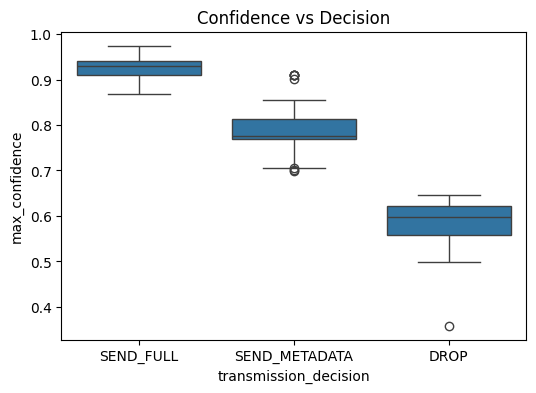

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x="transmission_decision", y="max_confidence", data=df)
plt.title("Confidence vs Decision")
plt.show()

Consecutive Fire Ratio

<Axes: >

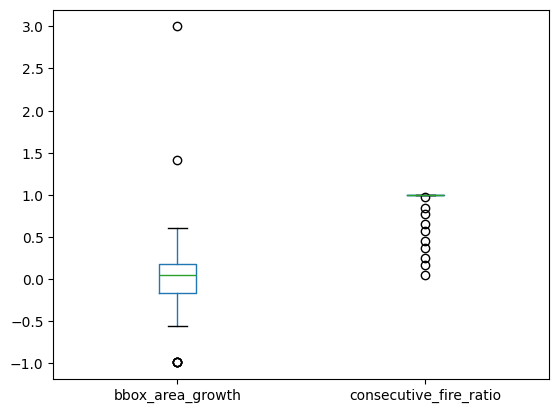

In [71]:
df.boxplot(column=["bbox_area_growth", "consecutive_fire_ratio"],grid=False)


Correlation check

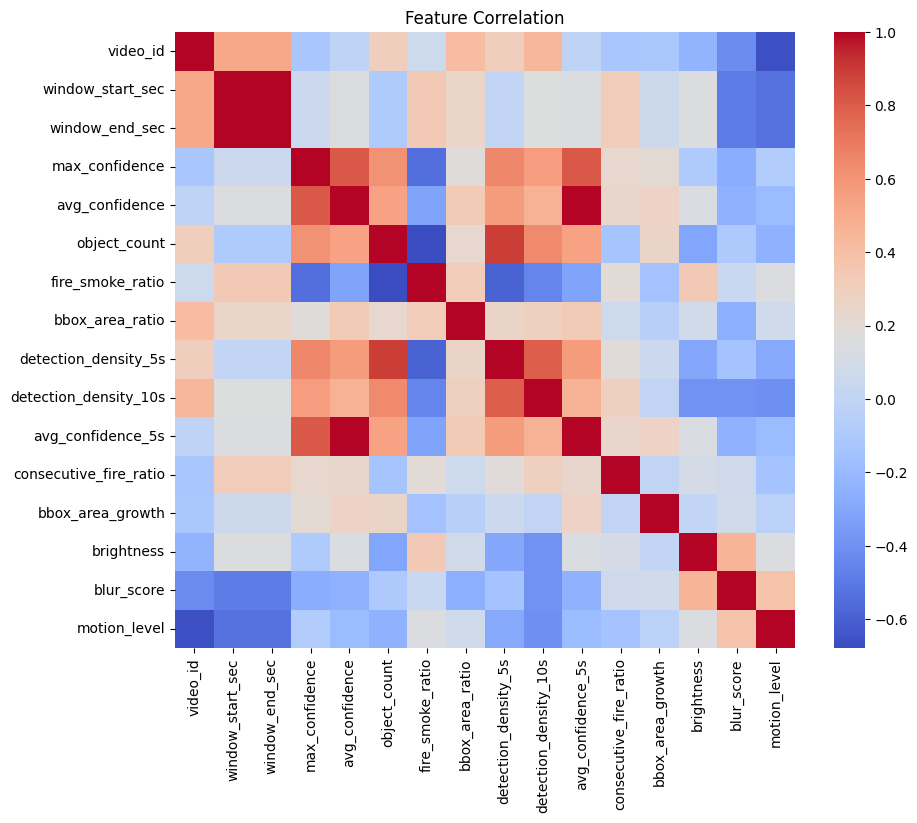

In [72]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

consecutive_fire_ratio histogram

<Axes: >

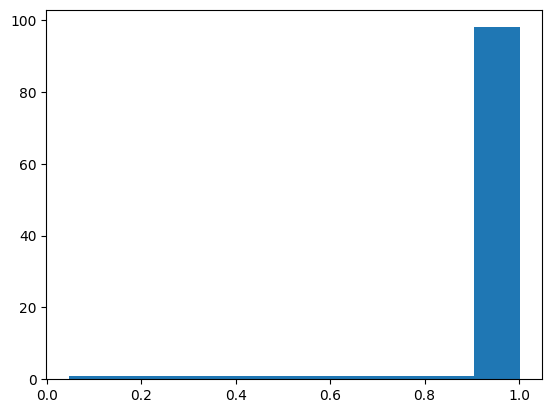

In [77]:
df["consecutive_fire_ratio"].hist(grid=False)

<Axes: >

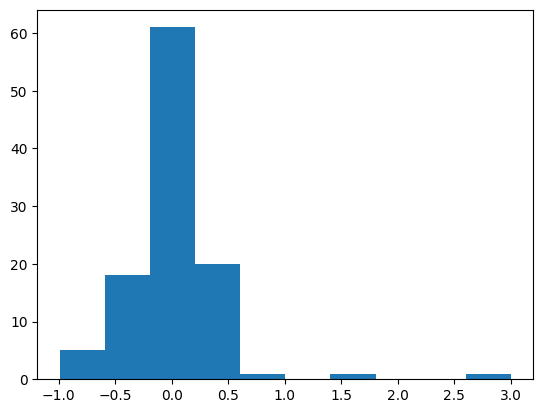

In [79]:
df["bbox_area_growth"].hist(grid=False)

Outliers check

In [ ]:
import pandas as pd

df = pd.read_csv("event_dataset_labeled.csv")
df.describe().T

,count,mean,std,min,25%,50%,75%,max
video_id,107.0,3.654206,0.790304,1.000000,4.000000,4.000000,4.000000,4.000000
window_start_sec,107.0,34.813084,27.304409,0.000000,7.500000,32.000000,58.500000,85.000000
window_end_sec,107.0,39.813084,27.304409,5.000000,12.500000,37.000000,63.500000,90.000000
representative_frame_id,107.0,1924.551402,951.905470,146.000000,1212.500000,2003.000000,2804.500000,3522.000000
max_confidence,107.0,0.769927,0.131271,0.358850,0.700699,0.776549,0.887288,0.974603
avg_confidence,107.0,0.458578,0.061594,0.278109,0.412412,0.459000,0.513355,0.582585
object_count,107.0,7.660410,5.187225,1.000000,4.036667,6.293333,9.103333,22.991304
fire_smoke_ratio,107.0,0.784981,0.199093,0.352060,0.631559,0.836892,0.966521,1.000000
bbox_area_ratio,107.0,0.706058,0.141655,0.252863,0.671665,0.739880,0.793756,0.877044
detection_density_5s,107.0,7.187871,4.527978,0.073407,4.015332,6.239573,8.782115,21.668335


In [73]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
video_id,107.0,3.654206,0.790304,1.000000,4.000000,4.000000,4.000000,4.000000
window_start_sec,107.0,34.813084,27.304409,0.000000,7.500000,32.000000,58.500000,85.000000
window_end_sec,107.0,39.813084,27.304409,5.000000,12.500000,37.000000,63.500000,90.000000
max_confidence,107.0,0.769927,0.131271,0.358850,0.700699,0.776549,0.887288,0.974603
avg_confidence,107.0,0.458578,0.061594,0.278109,0.412412,0.459000,0.513355,0.582585
object_count,107.0,7.660410,5.187225,1.000000,4.036667,6.293333,9.103333,22.991304
fire_smoke_ratio,107.0,0.784981,0.199093,0.352060,0.631559,0.836892,0.966521,1.000000
bbox_area_ratio,107.0,0.706058,0.141655,0.252863,0.671665,0.739880,0.793756,0.877044
detection_density_5s,107.0,7.187871,4.527978,0.073407,4.015332,6.239573,8.782115,21.668335
detection_density_10s,107.0,6.971809,3.831751,1.227895,4.143700,6.686687,8.792125,16.416416


In [2]:
import pandas as pd

df = pd.read_csv("event_dataset_raw.csv")
df.shape

(107, 18)

In [3]:
df.groupby("video_name").size()

video_name
cam01_car_fire.mp4      5
cam02_fire_test.mp4     6
cam03_smoke.mp4        10
cam04_wildfire.mp4     86
dtype: int64